<a href="https://colab.research.google.com/github/rafaelholder/CESAR-2026.2-ia-ciberseguranca./blob/main/aula2_fundamentos_ml_teachable_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança- Aula 2
## Fundamentos de ML e IA + classificador

**Dupla:** `Rafael Holder`  

Nesta aula a gente amarra os conceitos de ML (já vistos na aula anterior de conceitos básicos e análise de dados) e constrói **um classificador completo**, do treino ao uso. Vamos treinar esse modelo no **Teachable Machine** e carregá-lo aqui no notebook.

> Guarde bem o modelo e o conjunto de teste desta aula: **este classificador que você vai poder atacar na aula 10** (ataques de evasão).

Referência de apoio: Géron, *Hands-On Machine Learning*, caps. 1 (panorama) e 2 (projeto de ponta a ponta).

## Parte A - Conceitos

**Onde ML se situa dentro de IA**
- **IA** — qualquer sistema que exibe comportamento "inteligente".
  - **ML** — subárea da IA: o sistema *aprende padrões a partir de dados*, em vez de seguir regras escritas à mão.
    - **Deep learning** — ML com redes neurais profundas (é o que o Teachable Machine usa por baixo).
    - **LLMs** — modelos de linguagem de grande porte; um tipo específico de deep learning para texto. Retomados na Etapa 2 (segurança de LLMs).

**Tipos de aprendizado**
- **Supervisionado** — dados rotulados; o modelo aprende a mapear entrada → rótulo. *Ex. em segurança:* classificar e-mail como phishing ou legítimo. É o que faremos hoje.
- **Não supervisionado** — dados sem rótulo; o modelo encontra estrutura sozinho. *Ex.:* detecção de anomalias em fraude (aula 6).

**Treino / validação / teste** — separamos os dados em três para não nos enganarmos:
- **treino** ajusta o modelo; **validação** guia as escolhas (quando parar, qual configuração); **teste** mede o desempenho **em dados nunca vistos**. Medir no próprio treino infla o resultado.

**Sobreajuste (overfitting)** — o modelo decora o treino em vez de generalizar: vai muito bem no treino e mal no teste. O conjunto de teste independente é o que revela isso.

**Anatomia de um pipeline de ML** — a espinha de tudo que faremos no semestre:
1. dados → 2. representação/features → 3. treino → 4. avaliação → 5. uso (inferência).

Hoje cada etapa aparece de forma concreta: o Teachable Machine cuida de (1)–(3), e nós fazemos (4) e (5) aqui no notebook.

## Parte B — Classificador com o Teachable Machine

**Por que Teachable Machine?** Treina um classificador de imagem **sem código**, o que nivela a turma, e exporta um modelo Keras real (baseado em MobileNet). Esse mesmo modelo será o **alvo dos ataques de evasão na aula 10** — por isso construímos ele agora.

Link: https://teachablemachine.withgoogle.com/

### Passo 1 — Treinar o modelo (no navegador)
1. Abra o Teachable Machine → **Get Started** → **Image Project** → **Standard image model**.
2. Crie **2 ou 3 classes** simples e visualmente distintas (ex.: dois objetos diferentes, ou "com máscara" / "sem máscara").
3. Em cada classe, adicione **~40 a 80 imagens** (webcam ou upload). **Varie fundo, ângulo e iluminação** — isso é o que faz o modelo *generalizar* em vez de *decorar* (overfitting).
4. Clique em **Train Model** e teste na pré-visualização.


### Passo 2 — Exportar (e separar um teste honesto)
1. **Export Model** → aba **Tensorflow** → formato **Keras** → **Download my model**. Você recebe `converted_keras.zip` com `keras_model.h5` e `labels.txt`.
2. **Antes de sair**, separe de **10 a 15 imagens por classe que você NÃO usou no treino** — é o nosso conjunto de teste independente. Fotografe/junte à parte.

### Passo 3 — Organizar no Drive
Vamos colocar o modelo em `models/` e as imagens de teste em `data/test/<nome-da-classe>/`, usando **exatamente os mesmos nomes de classe** do Teachable Machine.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJETO = Path('/content/drive/MyDrive/ia-ciberseguranca')
(PROJETO / 'models').mkdir(parents=True, exist_ok=True)
(PROJETO / 'data' / 'test').mkdir(parents=True, exist_ok=True)

print('Coloque converted_keras.zip em:', PROJETO / 'models')
print('Coloque as imagens de teste em: ', PROJETO / 'data' / 'test' / '<classe>')

Mounted at /content/drive
Coloque converted_keras.zip em: /content/drive/MyDrive/ia-ciberseguranca/models
Coloque as imagens de teste em:  /content/drive/MyDrive/ia-ciberseguranca/data/test/<classe>


In [2]:
from pathlib import Path
import random, shutil, zipfile, urllib.request

PROJETO = Path('/content/drive/MyDrive/ia-ciberseguranca')
random.seed(42)

URLS = {
    'rps.zip':          'https://storage.googleapis.com/download.tensorflow.org/data/rps.zip',
    'rps-test-set.zip': 'https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip',
}
for nome, url in URLS.items():
    urllib.request.urlretrieve(url, nome)
    zipfile.ZipFile(nome).extractall('.')

CLASSES = ['rock', 'paper', 'scissors']
N_TREINO, N_TESTE = 70, 15

for c in CLASSES:
    treino = sorted(Path('rps', c).glob('*.png'))
    teste  = sorted(Path('rps-test-set', c).glob('*.png'))
    dst_tr = PROJETO / 'data' / 'tm_treino' / c
    dst_te = PROJETO / 'data' / 'test' / c
    dst_tr.mkdir(parents=True, exist_ok=True)
    dst_te.mkdir(parents=True, exist_ok=True)
    for f in random.sample(treino, N_TREINO):
        shutil.copy(f, dst_tr / f.name)
    for f in random.sample(teste, N_TESTE):
        shutil.copy(f, dst_te / f.name)
    print(f'{c:9s} → {N_TREINO} treino | {N_TESTE} teste')

rock      → 70 treino | 15 teste
paper     → 70 treino | 15 teste
scissors  → 70 treino | 15 teste


In [3]:
# Descompacta o modelo exportado do Teachable Machine
import zipfile

ZIP = PROJETO / 'models' / 'converted_keras.zip'
DEST = PROJETO / 'models'
with zipfile.ZipFile(ZIP) as z:
    z.extractall(DEST)

H5     = DEST / 'keras_model.h5'
LABELS = DEST / 'labels.txt'
print('Modelo :', H5.exists(), H5)
print('Labels :', LABELS.exists(), LABELS)

Modelo : True /content/drive/MyDrive/ia-ciberseguranca/models/keras_model.h5
Labels : True /content/drive/MyDrive/ia-ciberseguranca/models/labels.txt


### Carregar o modelo
O `.h5` do Teachable Machine é exportado com uma versão antiga do Keras e costuma **quebrar no TF atual do Colab** (erro clássico no `DepthwiseConv2D` por causa do argumento `groups`, e Keras 3 vs Keras 2). O bloco abaixo resolve os dois pontos: liga o modo de compatibilidade (Keras 2 via `tf_keras`) e aplica um patch na camada. Ele **precisa rodar antes de qualquer uso do TensorFlow** nesta sessão.

In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # carrega modelos Keras 2 (Teachable Machine) sob TF novo
%pip install -q tf_keras

import tensorflow as tf
from tensorflow.keras.layers import DepthwiseConv2D
print('TensorFlow', tf.__version__)

# Patch: versões antigas salvam 'groups' no DepthwiseConv2D; o Keras novo não entende
class PatchedDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, *args, **kwargs):
        kwargs.pop('groups', None)
        super().__init__(*args, **kwargs)

model = tf.keras.models.load_model(
    H5, compile=False,
    custom_objects={'DepthwiseConv2D': PatchedDepthwiseConv2D})

class_names = [l.strip().split(' ', 1)[-1]
               for l in open(LABELS, encoding='utf-8') if l.strip()]
print('Classes:', class_names)
model.summary()

TensorFlow 2.20.0
Classes: ['Rock', 'Paper', 'Scissors']
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 1280)              410208    
                                                                 
 sequential_3 (Sequential)   (None, 3)                 128400    
                                                                 
Total params: 538608 (2.05 MB)
Trainable params: 524528 (2.00 MB)
Non-trainable params: 14080 (55.00 KB)
_________________________________________________________________


### Pré-processamento e inferência
O Teachable Machine usa entrada **224×224 RGB** normalizada para o intervalo **[-1, 1]** (`pixel/127.5 - 1`). Precisamos replicar isso exatamente, senão a predição sai errada.

In [5]:
import numpy as np
from PIL import Image, ImageOps

try:
    RESAMPLE = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE = Image.LANCZOS

def carregar_imagem(caminho, tamanho=224):
    img = Image.open(caminho).convert('RGB')
    img = ImageOps.fit(img, (tamanho, tamanho), RESAMPLE)
    arr = np.asarray(img).astype(np.float32)
    return (arr / 127.5) - 1.0            # normalização do Teachable Machine

def prever(caminho):
    x = carregar_imagem(caminho)[None, ...]
    probs = model.predict(x, verbose=0)[0]
    i = int(np.argmax(probs))
    return class_names[i], float(probs[i]), probs

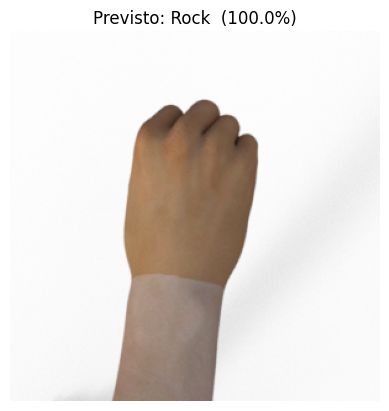

In [6]:
# Teste rápido com UMA imagem (aponte para um arquivo do seu data/test)
import matplotlib.pyplot as plt

exemplos = list((PROJETO / 'data' / 'test').rglob('*'))
exemplos = [p for p in exemplos if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
assert exemplos, 'Coloque imagens em data/test/<classe>/ antes de rodar.'

alvo = exemplos[2]
classe, conf, _ = prever(alvo)
plt.imshow(Image.open(alvo)); plt.axis('off')
plt.title(f'Previsto: {classe}  ({conf:.1%})')
plt.show()

### Treino / validação / teste — na prática
O Teachable Machine já separou **treino e validação** internamente enquanto treinava. Agora fazemos o que falta: medir o modelo no **nosso conjunto de teste independente**, com imagens que ele nunca viu. Se a acurácia aqui for bem menor que a mostrada no Teachable Machine, isso é **overfitting**.

In [8]:
# Padronizando os nomes das pastas para busca no drive
class_names = [c.lower() for c in class_names]
print('Classes:', class_names)

Classes: ['rock', 'paper', 'scissors']


Imagens de teste : 45
Acurácia no teste: 95.6%

              precision    recall  f1-score   support

       paper       1.00      0.87      0.93        15
        rock       0.88      1.00      0.94        15
    scissors       1.00      1.00      1.00        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



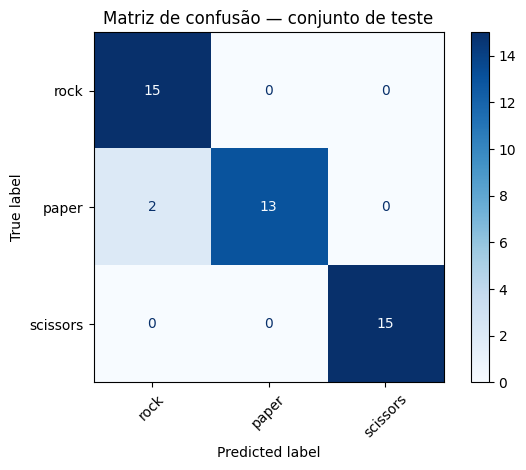

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

TEST_DIR = PROJETO / 'data' / 'test'
y_true, y_pred = [], []

for classe_dir in sorted(d for d in TEST_DIR.iterdir() if d.is_dir()):
    for img in classe_dir.glob('*'):
        if img.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        nome, _, _ = prever(img)
        y_true.append(classe_dir.name)
        y_pred.append(nome)

print(f'Imagens de teste : {len(y_true)}')
print(f'Acurácia no teste: {accuracy_score(y_true, y_pred):.1%}\n')
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=class_names)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de confusão — conjunto de teste')
plt.tight_layout(); plt.show()

### Discussão (respondam no notebook)
- A acurácia no **nosso teste** ficou próxima da que o Teachable Machine mostrou? Se caiu, **por quê**? (pista: variedade das imagens de treino)

- - Na validação interna do Teachable Machine, a acurácia foi de **100%** nas três classes (11 imagens de validação por classe, 33 no total). No nosso conjunto de teste independente, caiu para **95,6% (43 de 45 imagens)**, com os dois erros concentrados em paper.

- - A queda é pequena, mas tem explicação. A validação do Teachable Machine é tirada das **mesmas 70 imagens** que subimos para cada classe: são imagens do mesmo conjunto (`rps`), geradas com as mesmas mãos e poses do treino. Por isso ela tende a ser otimista. O nosso teste veio de um conjunto separado (`rps-test-set`), gerado com outras mãos e poses, e mede melhor o desempenho em dados realmente novos. O modelo não decorou o treino, porque 95,6% ainda é alto, mas a validação interna superestimou um pouco a capacidade dele de generalizar.

- - As duas amostras também são pequenas. Na validação, um único erro derrubaria a acurácia de uma classe em 9 pontos percentuais; no teste, cada erro pesa 2,2 pontos no total. Com números assim, 100% contra 95,6% é uma diferença de apenas duas imagens, e deve ser lida com cautela.

- Onde cada etapa do **pipeline** apareceu nesta aula? (dados → representação MobileNet → treino no TM → avaliação aqui → uso)

- - **Dados:** base Rock Paper Scissors do TensorFlow, com uma amostra de 70 imagens por classe para treino e 15 por classe, de um conjunto separado, para teste.
- - **Representação:** a MobileNet pré-treinada, usada por baixo pelo Teachable Machine, transforma cada imagem em um vetor de features (transfer learning). Só as camadas finais são treinadas com as nossas classes.
- - **Treino:** feito no Teachable Machine, que separa internamente parte das imagens para validação.
- - **Avaliação:** feita aqui no notebook, com acurácia, precisão, recall e matriz de confusão no conjunto de teste independente.
- - **Uso (inferência):** a função `prever()` classifica uma imagem nova, replicando exatamente o pré-processamento do treino (224×224 RGB, pixels normalizados para [-1, 1]).


- Que classe o modelo mais confunde? O que isso sugere sobre as *features* que ele aprendeu?

- - A única confusão foi **paper prevista como rock**, em 2 das 15 imagens (recall de 87% para paper). Por consequência, a precisão de rock caiu para 88%: das 17 imagens que o modelo chamou de rock, 2 eram paper. Rock e scissors tiveram 100% de recall, e nenhuma imagem foi confundida com scissors.

- - Isso sugere que o modelo se apoia bastante na **silhueta geral da mão**, e menos na separação entre os dedos. Uma mão aberta vista de lado, ou com os dedos juntos, forma uma mancha compacta parecida com um punho fechado. Já a tesoura tem uma forma muito característica (dois dedos estendidos em V) e nunca foi confundida.

- - A fronteira entre paper e rock é o ponto mais frágil do modelo. É ali que uma perturbação pequena na imagem teria mais chance de inverter a decisão, o que faz dela o alvo natural do ataque de evasão da aula 10.

In [10]:
# Guardar o modelo do projeto para reuso na aula 10 (ataques de evasão)
import shutil
shutil.copy(H5, PROJETO / 'models' / 'modelo_aula2.h5')
(PROJETO / 'models' / 'labels_aula2.txt').write_text('\n'.join(class_names) + '\n')
print('Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.')

Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.


## Entregável da aula
- [] Modelo treinado no Teachable Machine e carregado no notebook
- [] Inferência funcionando
- [] Avaliação no conjunto de teste independente (acurácia + matriz de confusão)
- [] Respostas da discussão
- [] `modelo_aula2.h5` e imagens de teste salvos no projeto

**Próxima aula:** dados e features em segurança — escolha da base do projeto e dicionário de features.
**Aula 10:** este mesmo modelo podera ser alvo de ataques de evasão. Não apague o `.h5` nem o conjunto de teste.